# Exploratory Data Analysis

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sys

sns.set_style("darkgrid")
pd.set_option("display.max_columns", 100)

ROOT = Path.cwd().parent.resolve()
DATASET_PATH = ROOT / "dataset" / "Airbnb_Data.csv"

df = pd.read_csv(DATASET_PATH)

df.head()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,NYC,"Beautiful, sunlit brownstone 1-bedroom in the ...",2016-06-18,t,t,NaN,2012-03-26,f,2016-07-18,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,NYC,Enjoy travelling during your stay in Manhattan...,2017-08-05,t,f,100%,2017-06-19,t,2017-09-23,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,NYC,The Oasis comes complete with a full backyard ...,2017-04-30,t,t,100%,2016-10-25,t,2017-09-14,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,SF,This light-filled home-away-from-home is super...,NaN,t,t,NaN,2015-04-19,f,NaN,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,DC,"Cool, cozy, and comfortable studio located in ...",2015-05-12,t,t,100%,2015-03-01,t,2017-01-22,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


In [2]:
df.dtypes

id                          int64
log_price                 float64
property_type                 str
room_type                     str
amenities                     str
accommodates                int64
bathrooms                 float64
bed_type                      str
cancellation_policy           str
cleaning_fee                 bool
city                          str
description                   str
first_review                  str
host_has_profile_pic          str
host_identity_verified        str
host_response_rate            str
host_since                    str
instant_bookable              str
last_review                   str
latitude                  float64
longitude                 float64
name                          str
neighbourhood                 str
number_of_reviews           int64
review_scores_rating      float64
thumbnail_url                 str
zipcode                       str
bedrooms                  float64
beds                      float64
dtype: object

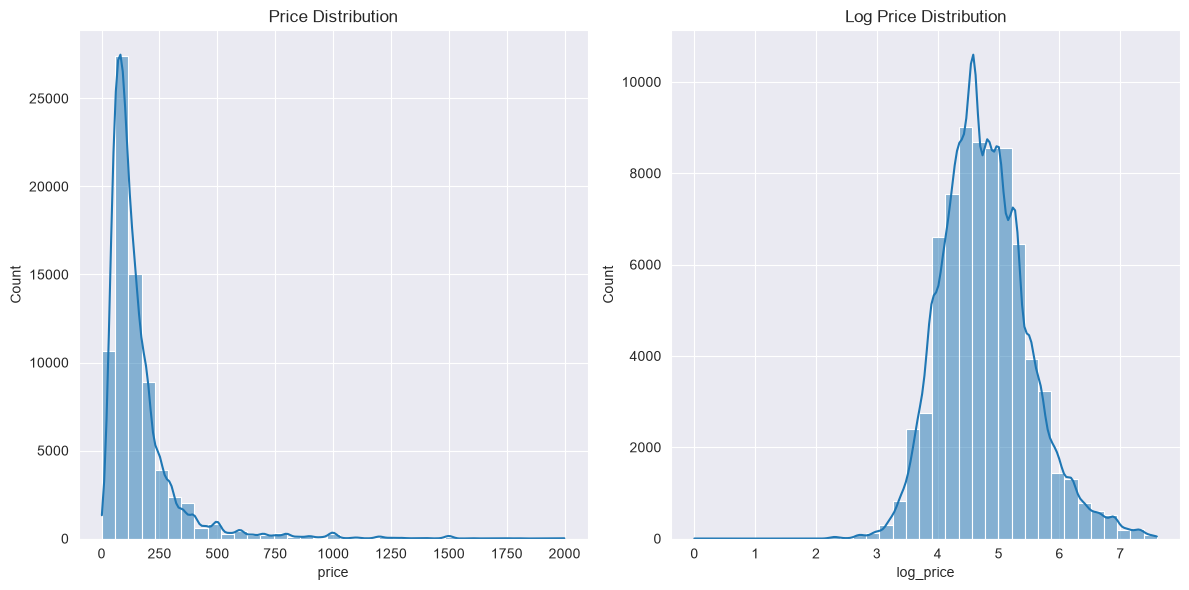

In [3]:
df['price'] = np.exp(df['log_price'])

fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(12, 6))
sns.histplot(data=df, x='price', bins=35, kde=True, ax=axes[0])
sns.histplot(data=df, x='log_price', bins=35, kde=True, ax=axes[1])

axes[0].set_title("Price Distribution")
axes[1].set_title("Log Price Distribution")

plt.tight_layout()
plt.show()

## NaN Report

In [4]:
nan_report = df.isna().mean().sort_values(ascending=False)
nan_report

host_response_rate        0.246913
review_scores_rating      0.225635
first_review              0.214057
last_review               0.213558
thumbnail_url             0.110861
neighbourhood             0.092726
zipcode                   0.013035
bathrooms                 0.002699
host_identity_verified    0.002537
host_since                0.002537
host_has_profile_pic      0.002537
beds                      0.001768
bedrooms                  0.001228
property_type             0.000000
city                      0.000000
description               0.000000
cancellation_policy       0.000000
cleaning_fee              0.000000
bed_type                  0.000000
room_type                 0.000000
amenities                 0.000000
accommodates              0.000000
log_price                 0.000000
id                        0.000000
latitude                  0.000000
instant_bookable          0.000000
name                      0.000000
longitude                 0.000000
number_of_reviews   

In [5]:
(df['last_review'].isna() == df['first_review'].isna()).mean()

np.float64(0.9995007488766849)

In [6]:
(
    (df['host_identity_verified'].isna() == df['host_since'].isna()) &
    (df['host_identity_verified'].isna() == df['host_has_profile_pic'].isna())
).mean()

np.float64(1.0)

In [7]:
df['host_response_rate'] = pd.to_numeric(
    df['host_response_rate'].str.replace("%", "", regex=False),
    errors="coerce"
)

df['host_response_rate'].describe()

count    55812.000000
mean        94.351967
std         16.341817
min          0.000000
25%        100.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: host_response_rate, dtype: float64

In [8]:
df['host_response_rate'].value_counts(normalize=True).head(10)

host_response_rate
100.0    0.774995
90.0     0.040798
80.0     0.019942
0.0      0.015821
50.0     0.010947
70.0     0.009102
99.0     0.008027
67.0     0.007758
98.0     0.007615
94.0     0.007185
Name: proportion, dtype: float64

In [9]:
(df['host_response_rate'].isna() == df['host_identity_verified'].isna()).mean()

np.float64(0.7556233217740956)

In [10]:
pd.crosstab(
    df['host_response_rate'].isna(),
    df['host_identity_verified'].isna()
)

host_identity_verified,False,True
host_response_rate,,
False,55812,0
True,18111,188


In [11]:
cols = nan_report[nan_report > 0].index.tolist()

for col in cols:
    print("\n-------------------------------------")
    print(df.groupby(df[col].isna())['price'].agg(
        ['count', 'mean', 'median']
    ))


-------------------------------------
                    count        mean  median
host_response_rate                           
False               55812  154.705726   110.0
True                18299  177.649489   115.0

-------------------------------------
                      count        mean  median
review_scores_rating                           
False                 57389  147.748297   110.0
True                  16722  203.690767   120.0

-------------------------------------
              count        mean  median
first_review                           
False         58247  147.794393   110.0
True          15864  206.547151   120.0

-------------------------------------
             count        mean  median
last_review                           
False        58284  147.785207   110.0
True         15827  206.718329   120.0

-------------------------------------
               count        mean  median
thumbnail_url                           
False          65895  153.18487

In [12]:
pd.crosstab(
    df['thumbnail_url'].isna(),
    df['first_review'].isna()
)

first_review,False,True
thumbnail_url,,
False,52325,13570
True,5922,2294


In [13]:
df.describe()

,id,log_price,accommodates,bathrooms,host_response_rate,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds,price
count,7.411100e+04,74111.000000,74111.000000,73911.000000,55812.000000,74111.000000,74111.000000,74111.000000,57389.000000,74020.000000,73980.000000,74111.000000
mean,1.126662e+07,4.782069,3.155146,1.235263,94.351967,38.445958,-92.397525,20.900568,94.067365,1.265793,1.710868,160.370849
std,6.081735e+06,0.717394,2.153589,0.582044,16.341817,3.080167,21.705322,37.828641,7.836556,0.852143,1.254142,168.580415
min,3.440000e+02,0.000000,1.000000,0.000000,0.000000,33.338905,-122.511500,0.000000,20.000000,0.000000,0.000000,1.000000
25%,6.261964e+06,4.317488,2.000000,1.000000,100.000000,34.127908,-118.342374,1.000000,92.000000,1.000000,1.000000,75.000000
50%,1.225415e+07,4.709530,2.000000,1.000000,100.000000,40.662138,-76.996965,6.000000,96.000000,1.000000,1.000000,111.000000
75%,1.640226e+07,5.220356,4.000000,1.000000,100.000000,40.746096,-73.954660,23.000000,100.000000,1.000000,2.000000,185.000000
max,2.123090e+07,7.600402,16.000000,8.000000,100.000000,42.390437,-70.985047,605.000000,100.000000,10.000000,18.000000,1999.000000


In [14]:
nan_report

host_response_rate        0.246913
review_scores_rating      0.225635
first_review              0.214057
last_review               0.213558
thumbnail_url             0.110861
neighbourhood             0.092726
zipcode                   0.013035
bathrooms                 0.002699
host_identity_verified    0.002537
host_since                0.002537
host_has_profile_pic      0.002537
beds                      0.001768
bedrooms                  0.001228
property_type             0.000000
city                      0.000000
description               0.000000
cancellation_policy       0.000000
cleaning_fee              0.000000
bed_type                  0.000000
room_type                 0.000000
amenities                 0.000000
accommodates              0.000000
log_price                 0.000000
id                        0.000000
latitude                  0.000000
instant_bookable          0.000000
name                      0.000000
longitude                 0.000000
number_of_reviews   

### Missing Value Analysis Conclusion

During the analysis of missing values, several features with missing values were identified. The highest proportion of missing values was found in:

* `host_response_rate` (~ 24.7%)
* `review_scores_rating` (~ 22.6%)
* `first_review` (~ 21.4%)
* `last_review` (~ 21.3%)
* `thumbnail_url` (~ 11.1%)
* `neighbourhood` (~ 9.3%)

The analysis showed that missing values in the dataset are **not random** and may represent meaningful information.

For *review-related* features (`first_review`, `last_review`), missing values show a strong relationship. In particular `first_review` and `last_review` have almost identical missingness patterns (~99%), suggesting that they represent the same factor: the presence and absence of review history.

Listings without review information have different price distributions compared to listings with reviews. Therefore, missing *review-related* values should not be removed as the absence of reviews itself may be an informative feature.

A similar pattern was observed for `host_response_rate`. The feature contains the largest proportion of missing values, while the available values are highly concentrated around 100%. Since missing values may indicate the absence of host interaction history rather than poor response performance, the missingness may carry predictive information.

The *host-related features* `host_has_profile_pic`, `host_identity_verified` and `host_since` were found to have identical missingness patterns across these features. This indicates that these missing values originate from the same issue. Creating one common flag, such as **host_missing** can be a possible solution.

The `thumbnail_url` feature also showed a meaningful relationship with price. Listings without thumbnail had a different price distribution, suggesting that the absence of an image may describe a specific group of listings rather than a random missing data.

Based on the analysis, the following preprocessing strategy will be considered for the modeling stage:

* Do not remove rows containing missing values, as many missing values appear to have specific predictive meaning.
* `host_response_rate` can be filled with median value, while preserving information through a binary indicator.
* Categorical features with missing values can be filled with **Unknown** value.
* *host-related features* may share one flag for missing values: **host_missing**. `host_since` is a **DateTime** feature and considered to transfrom DateTime information into host age(`days_count`) and fill missing values with median while preserving the missing flag.
* `thumbnail_url` is considered to be transformed into a binary feature.

----

## Duplicate Inspection

In [15]:
df_copy = df.drop(columns='id')

df_copy.duplicated().sum()

np.int64(0)

### Duplicate Inspection Conclusion

There are not duplicates in the dataset

## Target Variable Analysis

Goals for this section:

1. Understand price distribution
2. Identify skewness
3. Analyze asymmetry

In [16]:
df['price'].describe()

count    74111.000000
mean       160.370849
std        168.580415
min          1.000000
25%         75.000000
50%        111.000000
75%        185.000000
max       1999.000000
Name: price, dtype: float64

In [17]:
df[df['price'] == 1].T

,11632
id,17972519
log_price,0.0
property_type,Condominium
room_type,Shared room
amenities,"{TV,""Wireless Internet"",""Air conditioning"",Kit..."
accommodates,1
bathrooms,1.0
bed_type,Real Bed
cancellation_policy,strict
cleaning_fee,True


In [18]:
df[df['price'] <= 10]['city'].value_counts()

city
NYC    2
Name: count, dtype: int64

In [19]:
df[df['price'] <= 10]['room_type'].value_counts()

room_type
Entire home/apt    1
Shared room        1
Name: count, dtype: int64

In [20]:
df[df['price'] <= 6][[
    'price',
    'name',
    'room_type',
    'property_type',
    'accommodates',
    'bedrooms',
    'number_of_reviews',
    'review_scores_rating',
    'host_since'
]].T

,3898,11632
price,5.0,1.0
name,Upper West Side Studio Steps from Central Park,Esteem's Place
room_type,Entire home/apt,Shared room
property_type,Apartment,Condominium
accommodates,2,1
bedrooms,0.0,1.0
number_of_reviews,1,3
review_scores_rating,100.0,87.0
host_since,2013-08-14,2017-07-20


In [21]:
(df['log_price'] == 0).sum()

np.int64(1)

In [22]:
(df['log_price'] == 1).sum()

np.int64(0)

In [23]:
df['price'].nsmallest(20)

11632     1.0
3898      5.0
4466     10.0
6515     10.0
19806    10.0
21282    10.0
22268    10.0
23304    10.0
23917    10.0
25239    10.0
25655    10.0
26000    10.0
27021    10.0
28685    10.0
28693    10.0
37651    10.0
43269    10.0
48734    10.0
50577    10.0
52000    10.0
Name: price, dtype: float64

In [24]:
df.nsmallest(20, 'price')[[
    'city',
    'room_type',
    'property_type',
    'accommodates',
    'bedrooms',
    'number_of_reviews',
    'price'
]]

,city,room_type,property_type,accommodates,bedrooms,number_of_reviews,price
11632,NYC,Shared room,Condominium,1,1.0,3,1.0
3898,NYC,Entire home/apt,Apartment,2,0.0,1,5.0
4466,LA,Private room,Apartment,1,1.0,0,10.0
6515,Chicago,Private room,Apartment,1,1.0,78,10.0
19806,SF,Private room,Apartment,2,1.0,1,10.0
21282,Chicago,Shared room,House,2,1.0,1,10.0
22268,NYC,Private room,Apartment,2,1.0,0,10.0
23304,LA,Shared room,House,1,1.0,0,10.0
23917,NYC,Shared room,Apartment,1,1.0,2,10.0
25239,DC,Shared room,Apartment,4,1.0,41,10.0


In [25]:
df[df['price'] <= df['price'].quantile(0.01)][
    [
        'city',
        'room_type',
        'property_type',
        'accommodates',
        'bedrooms',
        'number_of_reviews',
        'price'
    ]
].sort_values('price')

,city,room_type,property_type,accommodates,bedrooms,number_of_reviews,price
11632,NYC,Shared room,Condominium,1,1.0,3,1.0
3898,NYC,Entire home/apt,Apartment,2,0.0,1,5.0
28685,DC,Private room,Apartment,2,1.0,20,10.0
4466,LA,Private room,Apartment,1,1.0,0,10.0
27021,LA,Entire home/apt,Apartment,5,1.0,0,10.0
...,...,...,...,...,...,...,...
29513,LA,Private room,Dorm,2,1.0,0,29.0
29950,Chicago,Private room,Apartment,2,1.0,13,29.0
74030,LA,Shared room,Apartment,1,1.0,0,29.0
238,LA,Private room,House,1,1.0,4,29.0


In [26]:
df['price'].quantile([
    0.001,
    0.005,
    0.01,
    0.02,
    0.05,
    0.1
])

0.001    15.0
0.005    25.0
0.010    29.0
0.020    33.0
0.050    40.0
0.100    50.0
Name: price, dtype: float64

In [27]:
df['price'].quantile([
    0.90,
    0.95,
    0.99,
    0.995,
    0.999
])

0.900     300.0
0.950     425.0
0.990     986.8
0.995    1200.0
0.999    1650.0
Name: price, dtype: float64

In [28]:
    df['price'].skew(), df['log_price'].skew()

(np.float64(4.298408387699143), np.float64(0.5146954132526466))

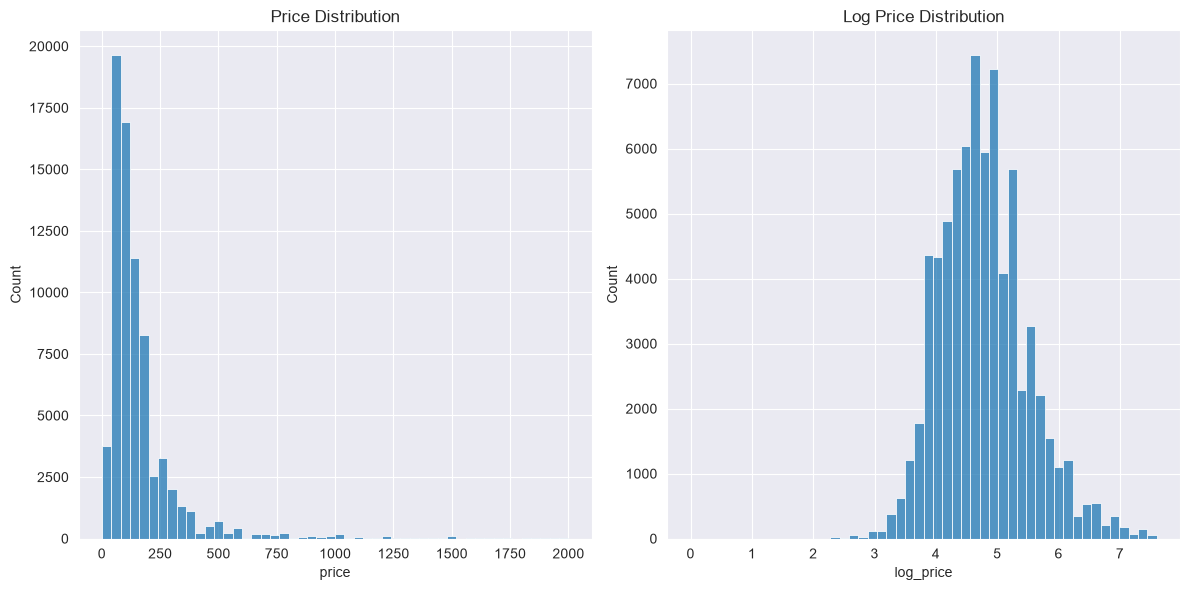

In [29]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(12, 6 ))

sns.histplot(data=df, x='price', bins=50, ax=axes[0])
sns.histplot(data=df, x='log_price', bins=50, ax=axes[1])

axes[0].set_title("Price Distribution")
axes[1].set_title("Log Price Distribution")

plt.tight_layout()
plt.show()

### Target Variable Analysis Conclusion

The target varibale `price` shows a strong right-skewed distribution with a skewness value of 4.30.

Most listings are connected in the lower price range, while a small number of expensive listings create a long right tail.

The analysis of quantiles shows that 90% of listings have a price below `$300`, while the top 1% of listings exceed approximately `$987`. These high-priced observations represent a small premium segment rather than obvious data errors.

The lower tail was also investigated. A single listing with a price of `$1` was identified. After examining its associated features, the observation appeared to be a valid but extremely low-priced listings. Since no clear data inconsistencies were found, these observations were retained.

The logarithmic transformation (`log_price`) significantly reduces the skewness from 4.30 to 0.51, resulting in a more balanced target distribution. Therefore, `log_price` will be used as a target variable for regression modeling.

## DateTime Analysis

In [30]:
date_cols = [
    'first_review',
    'host_since',
    'last_review'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

df[date_cols].dtypes

first_review    datetime64[us]
host_since      datetime64[us]
last_review     datetime64[us]
dtype: object

In [31]:
df[date_cols].describe()

,first_review,host_since,last_review
count,58247,73923,58284
mean,2016-01-14 08:11:51.013443,2014-07-21 01:55:09.849438,2017-03-14 19:27:18.789376
min,2008-11-17 00:00:00,2008-03-03 00:00:00,2009-01-21 00:00:00
25%,2015-06-28 00:00:00,2013-04-21 00:00:00,2017-01-09 00:00:00
50%,2016-05-25 00:00:00,2014-09-28 00:00:00,2017-04-28 00:00:00
75%,2017-01-02 00:00:00,2015-12-22 00:00:00,2017-09-08 00:00:00
max,2017-10-05 00:00:00,2017-10-04 00:00:00,2017-10-05 00:00:00


In [32]:
reference_date = df['host_since'].max()

df['host_age_days'] = (reference_date - df['host_since']).dt.days
df['host_age_days'].describe()

count    73923.000000
mean      1170.920025
std        661.497132
min          0.000000
25%        652.000000
50%       1102.000000
75%       1627.000000
max       3502.000000
Name: host_age_days, dtype: float64

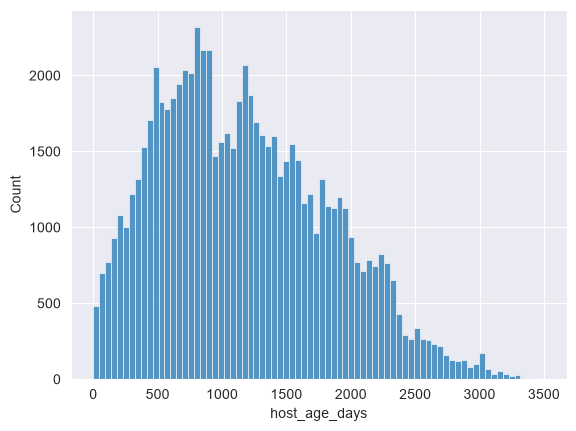

In [33]:
sns.histplot(data=df, x='host_age_days')
plt.show()

In [34]:
reference_date = df['last_review'].max()

df['days_since_last_review'] = (
    reference_date - df['last_review']
).dt.days

df['days_since_last_review'].describe()

count    58284.000000
mean       204.189366
std        231.729791
min          0.000000
25%         27.000000
50%        160.000000
75%        269.000000
max       3179.000000
Name: days_since_last_review, dtype: float64

In [35]:
df['review_history_days'] = (
    df['last_review'] - df['first_review']
).dt.days

df['review_history_days'].describe()

count    58247.000000
mean       425.461311
std        488.988636
min          0.000000
25%         52.000000
50%        264.000000
75%        623.000000
max       3106.000000
Name: review_history_days, dtype: float64

In [36]:
df['host_since_year'] = df['host_since'].dt.year
df['last_review_year'] = df['last_review'].dt.year
df['first_review_year'] = df['first_review'].dt.year

In [37]:
df[df['first_review'] < df['host_since']][[
    'host_since',
    'first_review',
    'last_review',
    'review_scores_rating',
    'price'
]]

,host_since,first_review,last_review,review_scores_rating,price
163,2013-09-25,2013-08-01,2017-09-20,88.0,90.0
950,2013-12-13,2012-05-21,2017-09-09,91.0,75.0
3828,2012-02-05,2011-12-24,2017-03-22,98.0,58.0
5401,2012-08-27,2012-07-23,2017-04-30,88.0,109.0
6736,2013-07-25,2012-10-27,2017-03-05,93.0,100.0
7634,2012-03-04,2011-07-11,2017-09-19,93.0,480.0
8097,2015-10-15,2015-07-06,2017-04-27,96.0,180.0
8888,2013-11-20,2013-05-06,2016-12-25,95.0,450.0
11237,2013-11-20,2012-04-01,2017-04-03,100.0,190.0
12765,2013-10-06,2013-05-06,2016-09-14,93.0,90.0


In [38]:
(df['first_review'] < df['host_since']).sum()

np.int64(44)

In [39]:
df['review_before_host'] = (
    df['first_review'] < df['host_since']
).astype(int)

In [40]:
datetime_features = [
    'host_age_days',
    'days_since_last_review',
    'review_history_days',
    'review_before_host'
]

df[datetime_features + ['log_price']].corr()['log_price'].sort_values()

review_before_host        0.007554
days_since_last_review    0.021550
review_history_days       0.073443
host_age_days             0.078333
log_price                 1.000000
Name: log_price, dtype: float64

In [41]:
df.groupby('host_since_year')['price'].agg(
    ['median', 'mean', 'count']
)

,median,mean,count
host_since_year,,,
2008.0,95.0,137.439560,91
2009.0,129.0,162.646132,698
2010.0,125.0,157.367497,1766
2011.0,125.0,170.343769,4887
2012.0,120.0,163.315359,8308
2013.0,120.0,162.920775,10729
2014.0,114.0,161.452009,13690
2015.0,108.0,157.326087,15594
2016.0,100.0,159.080667,13190


In [42]:
df.groupby('first_review_year')['price'].agg(
    ['median', 'mean', 'count']
)

,median,mean,count
first_review_year,,,
2008.0,36.0,36.000000,1
2009.0,120.0,129.160714,56
2010.0,124.5,140.388889,252
2011.0,125.0,152.956835,695
2012.0,125.0,164.444444,1503
2013.0,125.0,163.519231,2704
2014.0,120.0,158.356285,5243
2015.0,115.0,151.024842,12036
2016.0,109.0,145.647866,20779


In [43]:
df.groupby('first_review_year')['number_of_reviews'].median()

first_review_year
2008.0    31.0
2009.0    75.0
2010.0    68.5
2011.0    57.0
2012.0    42.0
2013.0    40.0
2014.0    28.0
2015.0    16.0
2016.0    10.0
2017.0     4.0
Name: number_of_reviews, dtype: float64

### DataTime Analysis Conclusion

The datetime features `host_since`, `first_review` and `last_review` were converted from string format and analyzed to identify potential temporal patterns related to the target variable.

The analysis showed that `host_since` represents the registration date of the host rather than the creation date of the listing. Therefore, direct comparison between host-related and listing-related dates should be interpreted carefully.

During the analysis, a small number of listings were identified where the first review date was earlier than the host registration date. Although this pattern may initially appear to indicate inccorect data, further investigation showed that these observations contained valid listing information and realistic feature values. Such cares may occur due to platform history, listing transfers, or changes related to host accounts. Since these observations represented only a very small fraction of the dataset and no clear inconsistencies were found, they are retained.

Several temporal patterns were identified. Older hosts and listings with longer review history showed slightly higher median prices, although the relationships were weak. This suggests that temporal information may provide additional predictive value, but it is unlikely to be one of the strongest prices drivers compared to structural and location-based features.

The following datetime-based features are reccomended for creation during preprocessing stage:

* `host_age_days` - number of days since the host joined the platform;
* `review_history_days` - duration between the first and last review;
* `days_since_last_review` - recency of the latest review activity;
* `first_review_year` - year when the listing received its first review;
* `host_since_year` - year when the host joined the platform;
* `has_reviews` - binary indicator showing whether the listing has review history;
* `review_before_host` - binary indicator for rare cases where the first review date is earlier than the host registration date;

Overall, datetime features will be included as additional model inputs, while expecting their contribution to be smaller compared to features describing property charasteristics, location and capacity.

## Numerical Feature Analysis

In [46]:
num_cols = [
    'accommodates',
    'bathrooms',
    'host_response_rate',
    'number_of_reviews',
    'review_scores_rating',
    'bedrooms',
    'beds'
]